<a href="https://colab.research.google.com/github/Krishna62186/Machine-Learning-IRIS/blob/main/ML_Iris_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Dataset – Exploratory Data Analysis
Run the cells top to bottom in Google Colab.

## 1. Setup & load data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

In [ ]:

from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Structure & data quality

In [ ]:
print("Shape:", df.shape)
print()
df.info()

Shape: (150, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
# Drop the Id column (just a row index) and tidy species names
df = df.drop(columns="Id")
df["Species"] = df["Species"].str.replace("Iris-", "", regex=False)
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
num_cols = df.select_dtypes("number").columns.tolist()
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("Missing values:\n", df.isna().sum(), "\n")
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)]

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64 

Duplicate rows: 3


,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
34,4.9,3.1,1.5,0.1,setosa
37,4.9,3.1,1.5,0.1,setosa
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [ ]:
# Duplicates are legitimate measurements in Iris; we keep them (remove with df.drop_duplicates() if desired)
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


## 3. Summary statistics

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [ ]:
df.groupby("species")[num_cols].agg(["mean", "std", "min", "max"]).round(2).T

species            setosa  versicolor  virginica
sepal_length mean    5.01        5.94       6.59
             std     0.35        0.52       0.64
             min     4.30        4.90       4.90
             max     5.80        7.00       7.90
sepal_width  mean    3.42        2.77       2.97
             std     0.38        0.31       0.32
             min     2.30        2.00       2.20
             max     4.40        3.40       3.80
petal_length mean    1.46        4.26       5.55
             std     0.17        0.47       0.55
             min     1.00        3.00       4.50
             max     1.90        5.10       6.90
petal_width  mean    0.24        1.33       2.03
             std     0.11        0.20       0.27
             min     0.10        1.00       1.40
             max     0.60        1.80       2.50

In [ ]:
# Skewness, kurtosis and coefficient of variation
summary = pd.DataFrame({
    "skew": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurt(),
    "CV (%)": df[num_cols].std() / df[num_cols].mean() * 100,
}).round(3)
summary

,skew,kurtosis,CV (%)
sepal_length,0.315,-0.552,14.171
sepal_width,0.334,0.291,14.198
petal_length,-0.274,-1.402,46.943
petal_width,-0.105,-1.340,63.667


## 4. Univariate analysis

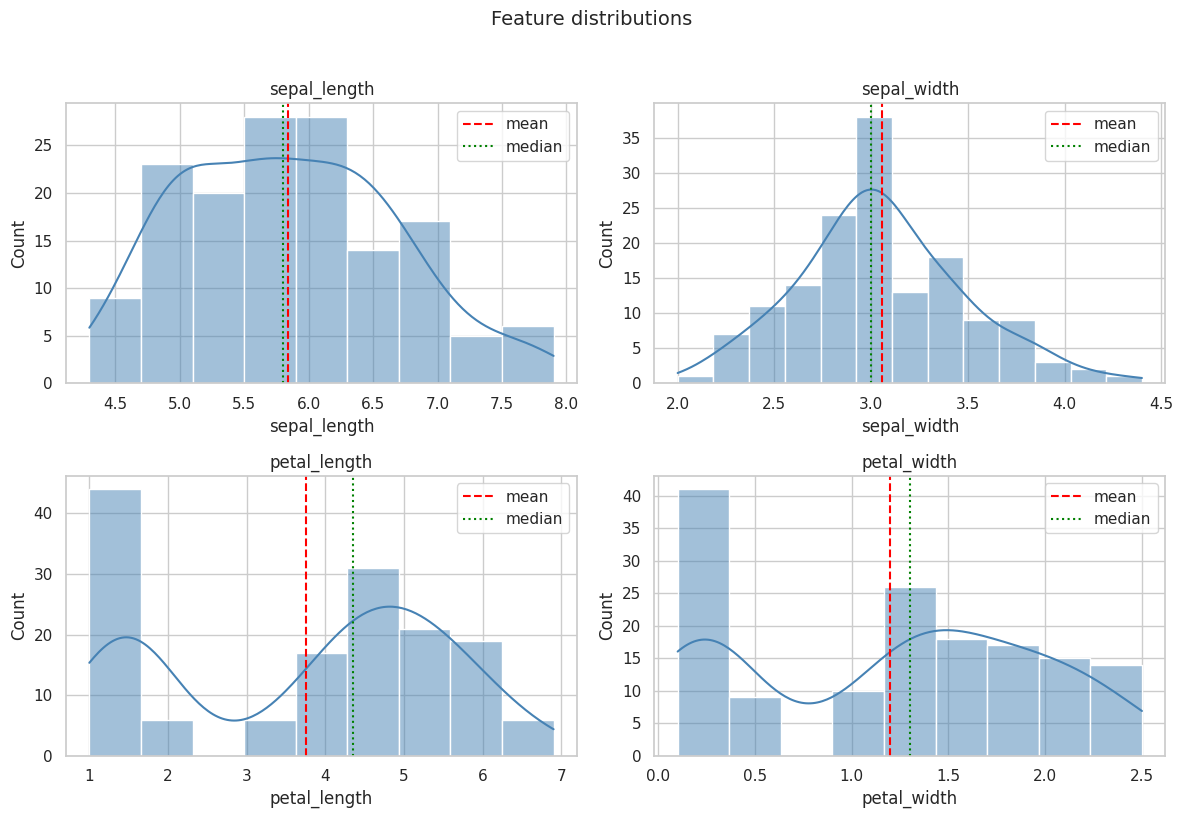

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.axvline(df[col].mean(), color="red", ls="--", label="mean")
    ax.axvline(df[col].median(), color="green", ls=":", label="median")
    ax.set_title(col); ax.legend()
plt.suptitle("Feature distributions", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Normality check (Shapiro-Wilk): p < 0.05 suggests non-normal
for col in num_cols:
    stat, p = stats.shapiro(df[col])
    print(f"{col:13s} W={stat:.3f}  p={p:.4f}  ->", "normal" if p > 0.05 else "not normal")

sepal_length  W=0.976  p=0.0102  -> not normal
sepal_width   W=0.984  p=0.0752  -> normal
petal_length  W=0.876  p=0.0000  -> not normal
petal_width   W=0.903  p=0.0000  -> not normal


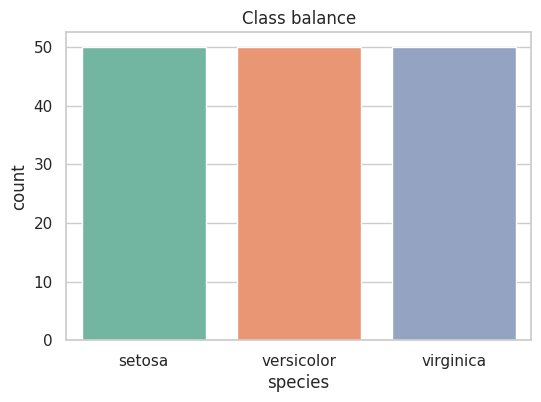

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="species", hue="species", legend=False)
plt.title("Class balance"); plt.show()

## 5. Outlier detection (IQR method)

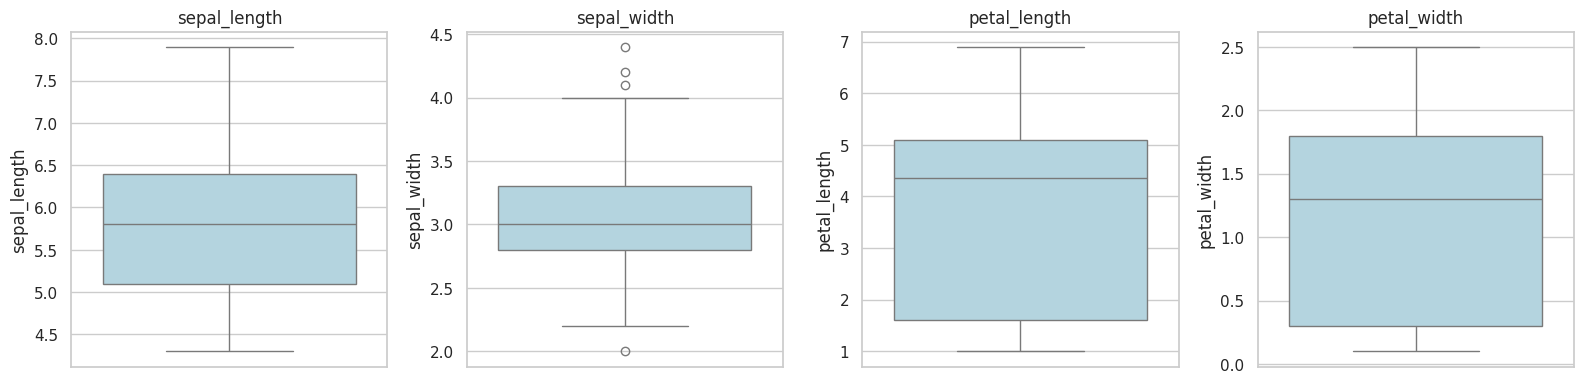

sepal_length  outliers: 0
sepal_width   outliers: 4


,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor


petal_length  outliers: 0
petal_width   outliers: 0


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightblue")
    ax.set_title(col)
plt.tight_layout(); plt.show()

for col in num_cols:
    q1, q3 = df[col].quantile([.25, .75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)
    print(f"{col:13s} outliers: {mask.sum()}")
    if mask.sum():
        display(df.loc[mask])

## 6. Feature vs. species

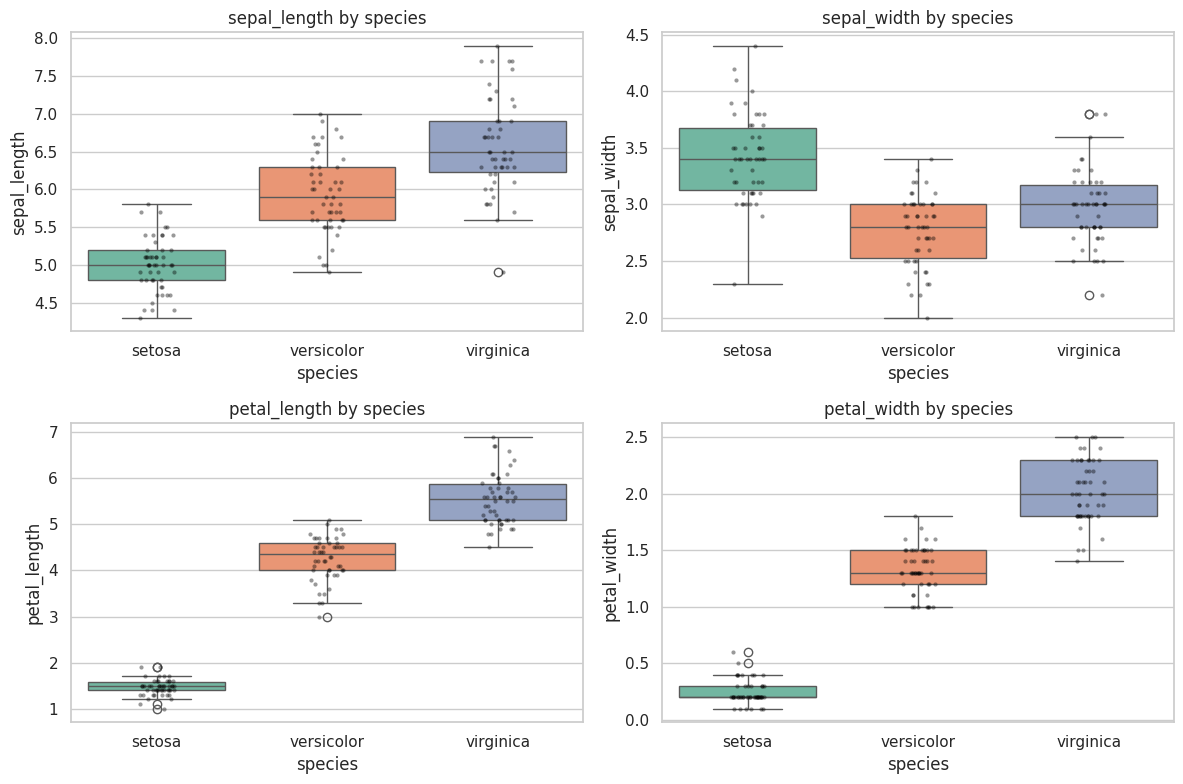

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x="species", y=col, hue="species", ax=ax, legend=False)
    sns.stripplot(data=df, x="species", y=col, color="black", alpha=.4, size=3, ax=ax)
    ax.set_title(f"{col} by species")
plt.tight_layout(); plt.show()

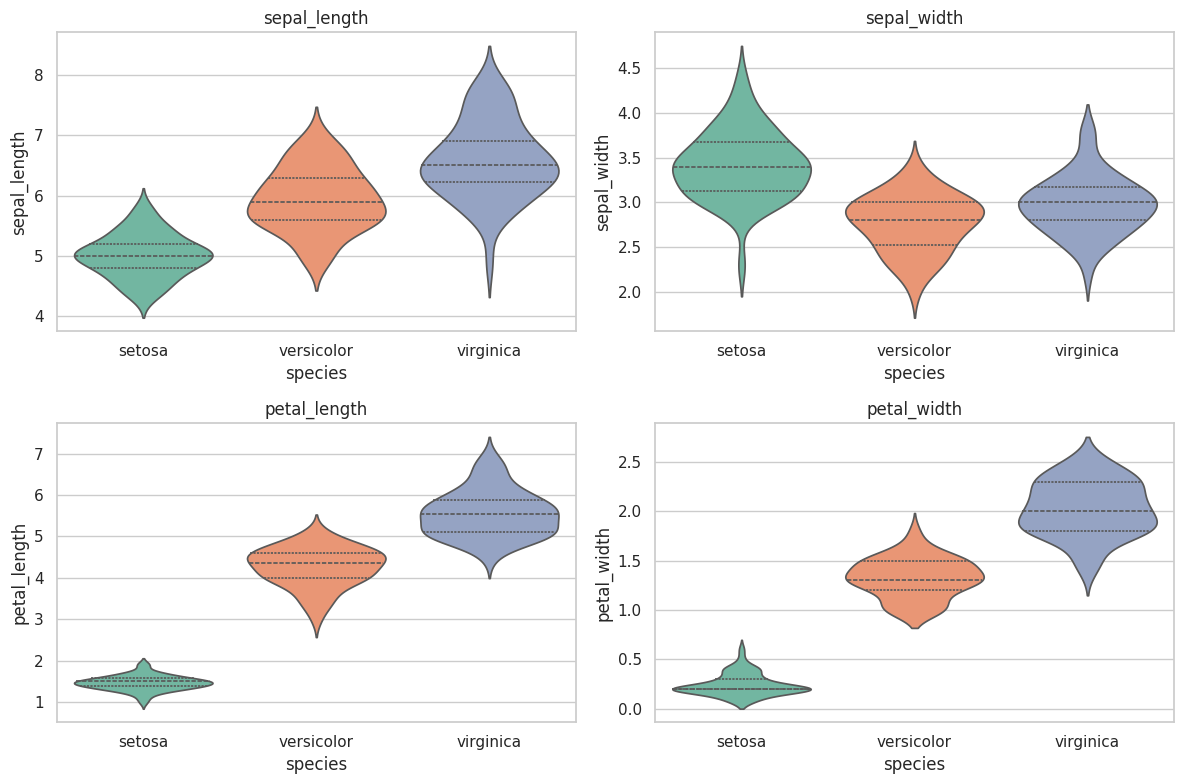

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.violinplot(data=df, x="species", y=col, hue="species", inner="quartile", ax=ax, legend=False)
    ax.set_title(col)
plt.tight_layout(); plt.show()

In [ ]:
# Do the species differ significantly? One-way ANOVA + Kruskal-Wallis
rows = []
for col in num_cols:
    groups = [g[col].values for _, g in df.groupby("species")]
    f, p_anova = stats.f_oneway(*groups)
    h, p_kw = stats.kruskal(*groups)
    rows.append([col, f, p_anova, h, p_kw])
pd.DataFrame(rows, columns=["feature", "F", "ANOVA p", "H", "Kruskal p"]).round(4)

,feature,F,ANOVA p,H,Kruskal p
0,sepal_length,119.2645,0.0,96.9374,0.0
1,sepal_width,47.3645,0.0,62.4946,0.0
2,petal_length,1179.0343,0.0,130.4141,0.0
3,petal_width,959.3244,0.0,131.0934,0.0


## 7. Multivariate analysis

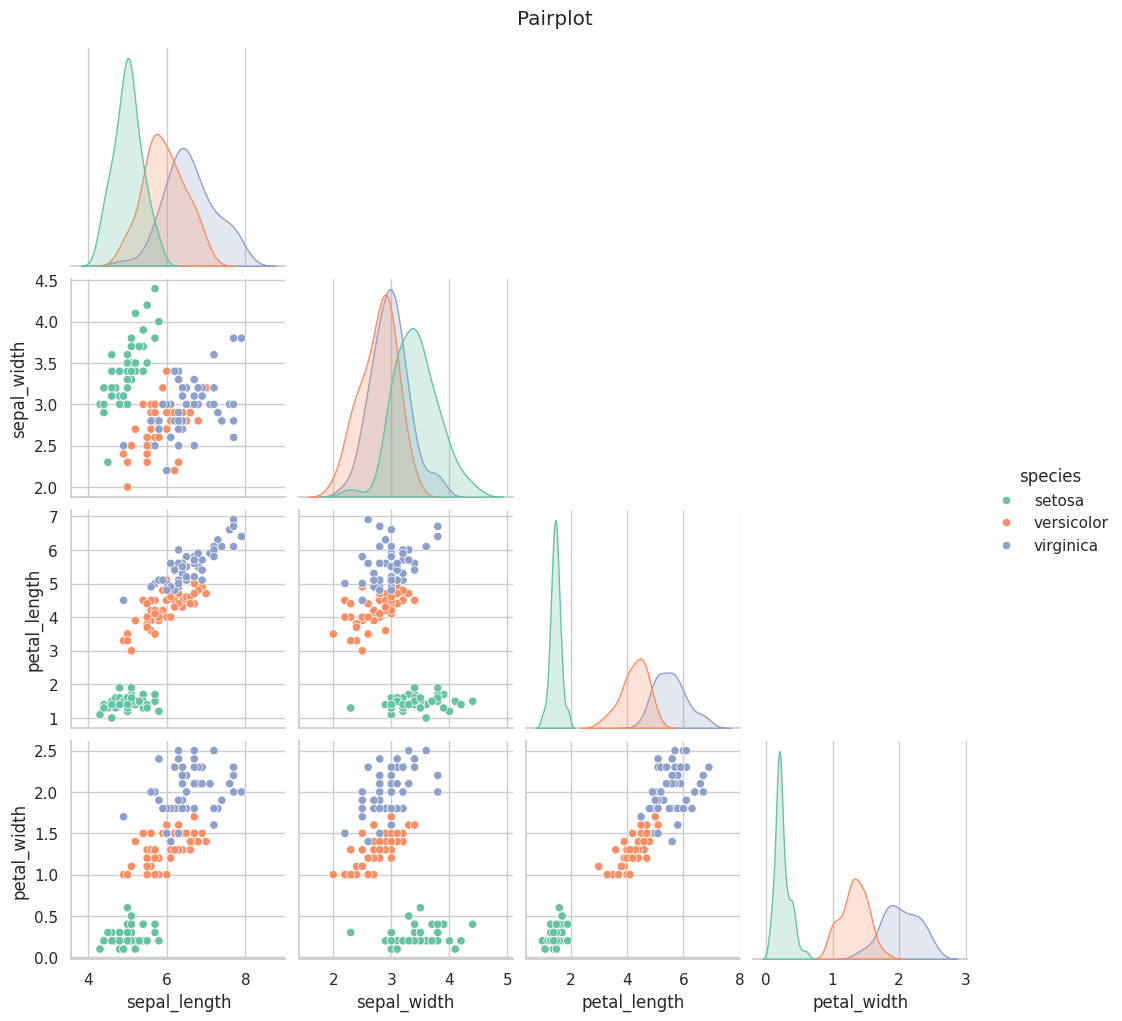

In [ ]:
sns.pairplot(df, hue="species", diag_kind="kde", corner=True)
plt.suptitle("Pairplot", y=1.02); plt.show()

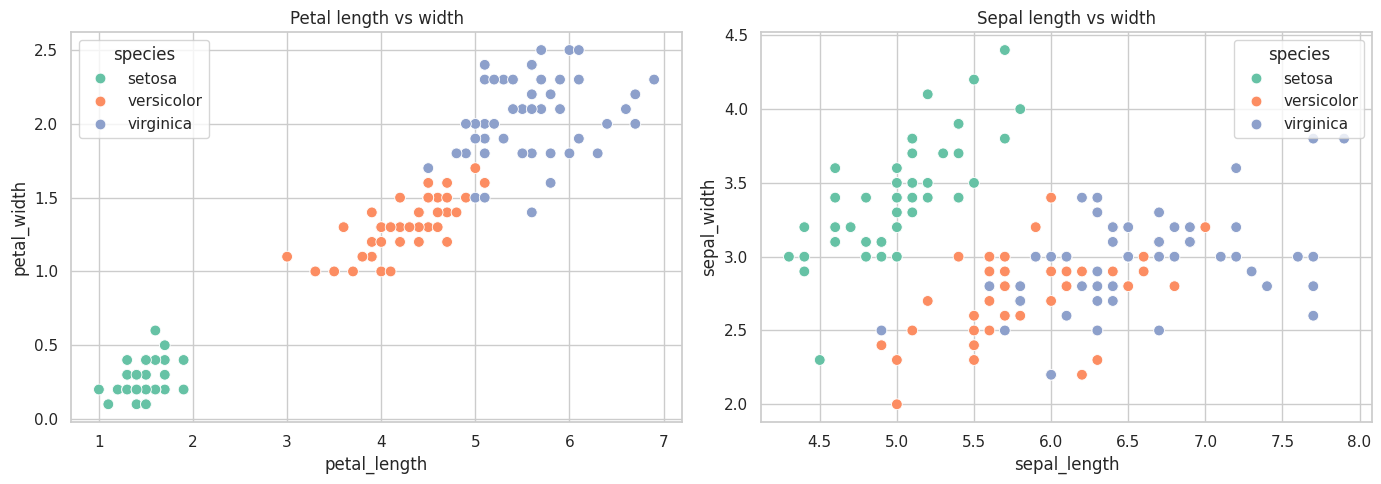

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", s=60, ax=axes[0])
axes[0].set_title("Petal length vs width")
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", hue="species", s=60, ax=axes[1])
axes[1].set_title("Sepal length vs width")
plt.tight_layout(); plt.show()

## 8. Correlation analysis

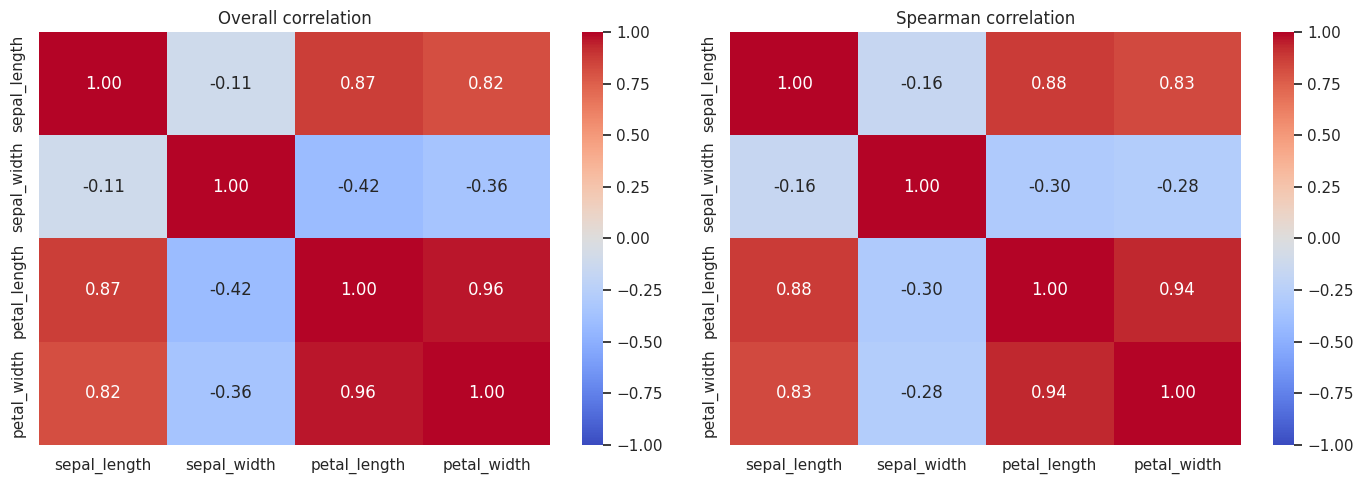

Sepal length vs sepal width correlation within each species:
species
setosa        0.747
versicolor    0.526
virginica     0.457
Name: sepal_length, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[0])
axes[0].set_title("Overall correlation")
# Within-species correlation reveals hidden structure (Simpson's paradox for sepal width)
within = df.groupby("species")[num_cols].corr().xs("sepal_width", level=1)["sepal_length"]
sns.heatmap(df[num_cols].corr(method="spearman"), annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[1])
axes[1].set_title("Spearman correlation")
plt.tight_layout(); plt.show()

print("Sepal length vs sepal width correlation within each species:")
print(within.round(3))

## 9. Dimensionality reduction (PCA)

Explained variance ratio: [0.728 0.23  0.037 0.005]
Cumulative: [0.728 0.958 0.995 1.   ]


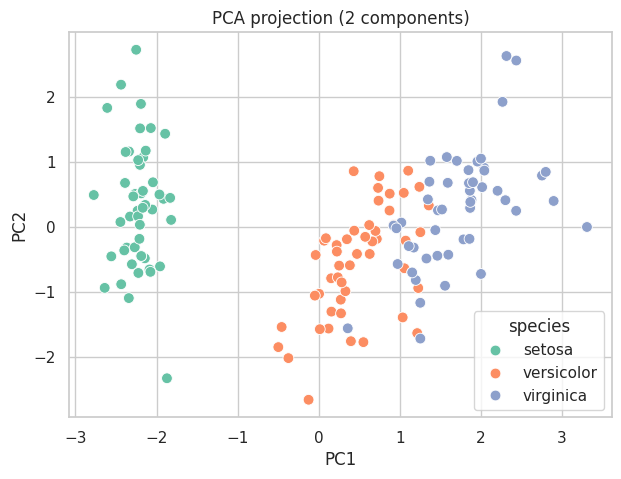

,PC1,PC2
sepal_length,0.522,0.372
sepal_width,-0.263,0.926
petal_length,0.581,0.021
petal_width,0.566,0.065


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(df[num_cols])
pca = PCA().fit(X)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Cumulative:", pca.explained_variance_ratio_.cumsum().round(3))

pcs = pd.DataFrame(pca.transform(X)[:, :2], columns=["PC1", "PC2"])
pcs["species"] = df["species"]
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pcs, x="PC1", y="PC2", hue="species", s=60)
plt.title("PCA projection (2 components)"); plt.show()

pd.DataFrame(pca.components_[:2].T, index=num_cols, columns=["PC1", "PC2"]).round(3)

## 10. Quick separability check

Random forest 5-fold CV accuracy: 0.967


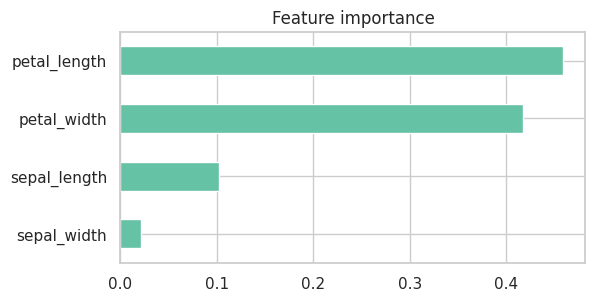

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
print("Random forest 5-fold CV accuracy:", cross_val_score(rf, df[num_cols], df["species"], cv=5).mean().round(3))

rf.fit(df[num_cols], df["species"])
pd.Series(rf.feature_importances_, index=num_cols).sort_values().plot.barh(title="Feature importance", figsize=(6, 3))
plt.show()

## 11. Key takeaways
- **150 rows, 4 numeric features, 3 perfectly balanced classes (50 each)**; no missing values.
- **Setosa** is clearly separable from the other two species, mostly via petal length/width.
- **Versicolor and virginica** overlap slightly, mainly in sepal measurements.
- **Petal length and petal width** are the strongest discriminators and are highly correlated (~0.96).
- **Sepal width** is the weakest feature and shows a few mild outliers.
- The first two principal components capture ~96% of variance, so the data is effectively 2-dimensional.
- Data is clean and well suited to classification models (logistic regression, KNN, SVM, tree-based).